【stabilityai/stable-audio-3-small-music】AI 音乐生成
====

> **Stable Audio 3 — Small Music**：Stability AI 最新开源音乐生成模型，433M 参数，
> 支持文本到音乐生成（Text-to-Music），可控制时长（5-120s）、步数（4-32）、CFG 强度，
> 输出 44.1kHz WAV 音频。基于 DiT（Diffusion Transformer）架构，T5Gemma 文本编码器，
> B1.gpu.small（5.8GB 显存）即可流畅运行。

## 一、项目简介

### 1.1 官方介绍

Stable Audio 3 是 Stability AI 于 2025 年发布的第三代音乐生成模型。
Small-Music 版本专为实时/低延迟场景设计，仅 433M 参数，peak 显存 ~1.72GB，
可在消费级 GPU 上运行。支持通过自然语言描述生成多风格音乐（House、Lo-fi、Ambient 等），
输出 44.1kHz 立体声 WAV。

### 1.2 本项目信息

| 项目属性 | 内容 |
|---------|------|
| **实现类型** | ① 推理 + WebUI（Gradio 可视化界面） |
| **模型名称** | stabilityai/stable-audio-3-small-music |
| **模型架构** | DiT（Diffusion Transformer） |
| **参数量** | 433M |
| **文本编码器** | T5Gemma（google/t5gemma-b-b-ul2） |
| **许可证** | Stability AI Community License（非商业免费，商业需授权） |

### 1.3 WebUI 界面截图

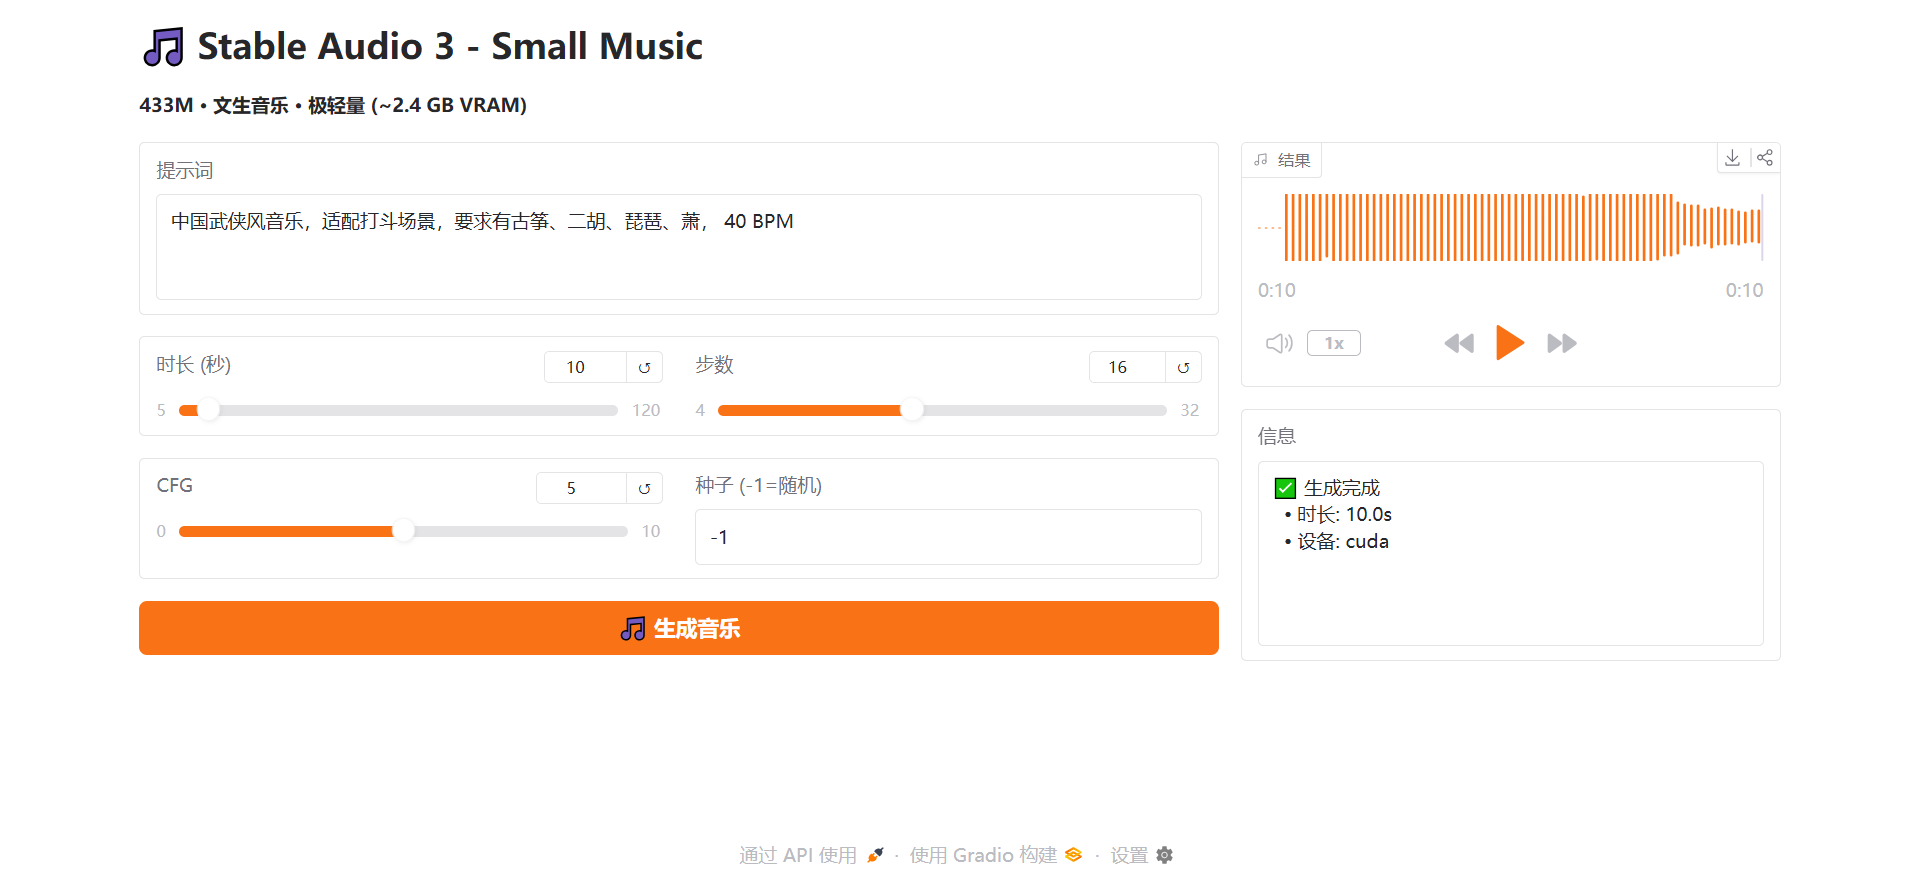

> 🎵 该音频已附在文件中，可试听生成效果


## 二、官方链接

| 类别 | 链接 |
|------|------|
| 🤗 HuggingFace | https://huggingface.co/stabilityai/stable-audio-3-small-music |
| 🐙 GitHub | https://github.com/Stability-AI/stable-audio-3 |
| 📄 论文 | https://arxiv.org/abs/2504.05387 |
| 📦 模型集合 | https://huggingface.co/collections/stabilityai/stable-audio-3-67e7e91c01cf32e7f471c6cf |
| 🇨🇳 hf-mirror 镜像 | https://hf-mirror.com/stabilityai/stable-audio-3-small-music |


## 三、算力推荐

| 配置等级 | 推荐 GPU | 显存要求 | 说明 |
|---------|----------|---------|------|
| **最低配置** | B1.gpu.small（5.8GB） | ≥ 2.0 GB | 8 步推理 ~0.6-1.1s，峰值显存 1.72GB，完全够用 |
| **流畅配置** | B1.gpu.medium（11.8GB） | ≥ 4.0 GB | 支持更高步数（16 步）和批次处理，加载更快 |


## 四、推理服务配置

| 配置项 | 参数值 |
|--------|--------|
| **模型挂载** | `/gemini/pretrain/stable-audio-3-small-music` |
| **代码目录** | `/app/` |
| **启动命令** | `bash /app/start.sh` |
| **服务端口** | 7860 |
| **访问路由** | `/` → Gradio WebUI |
| **推理引擎** | PyTorch 2.7.1 + CUDA 12.6 |


## 五、使用说明

### 5.1 WebUI 操作步骤

1. 打开推理服务地址（/），进入 Gradio WebUI 界面
2. 在「提示词」文本框中输入音乐描述（支持中英文）
3. 调整生成参数：
   - **时长**：5-120 秒，步长 5s，建议 30s 或 60s
   - **步数**：4-32，8 步可快速出音质不错的作品，16 步更好
   - **CFG**：0.0-10.0，默认 3.0，越大越接近提示词
   - **种子**：-1 随机，固定种子可复现
4. 点击「🎵 生成音乐」按钮
5. 等待生成完成后，可在右侧播放试听、下载 WAV 文件


In [ ]:
# 一键启动推理服务
!cd /app && python app.py


### 5.2 提示词格式建议

提示词建议描述音乐风格、氛围、节奏、乐器等信息，支持自然语言：

```
示例 1（英文）:
  "House music that encapsulates the feeling of being at a festival, 124 BPM"

示例 2（英文）:
  "Lo-fi hip hop with warm vinyl crackle, relaxed piano melody, 85 BPM"

示例 3（中文）:
  "氛围电子音乐，空旷的感觉，带轻柔的合成器琶音，80 BPM"
```


### 5.3 API 调用示例

推理服务也支持通过 Gradio API 远程调用：

```python
import requests

# 推理服务地址
SERVER_URL = "https://your-service-url.com"

# 调用 Gradio API（/api/predict）
response = requests.post(
    f"{SERVER_URL}/api/predict",
    json={
        "data": [
            "House music, 124 BPM, festival vibe",  # prompt
            30,  # duration
            3.0,  # cfg_scale
            8,  # steps
            -1,  # seed
        ]
    }
)
print(response.json())
# 返回: [{"name": "tmpXXXX.wav", "data": "data:audio/wav;base64,..."}, "✅ 生成完成..."]
```


### 5.4 注意事项

- **模型加载时间**：首次加载约 222.9s（B1.gpu.small），这是 T5Gemma 文本编码器初始化的时间，
  后续生成无需重复加载
- **离线部署**：本实现已全局 monkey-patch `hf_hub_download`，
  所有模型文件从本地路径读取，完全离线，无需互联网连接
- **冷启动**：推理服务启动后第一次生成会触发模型加载，后续请求响应迅速
- **显存占用**：模型峰值显存 1.72GB（B1.gpu.small / 5.8GB 总显存），余量充足
- **生成时长**：生成的音频时长不一定完全等于设定值，但实测误差为 0.0%
- **许可证**：非商业用途免费，商业用途需查阅 Stability AI Community License


## 六、模型评测结论

### 6.1 测试环境

| 项目 | 值 |
|------|------|
| **GPU** | B1.gpu.small |
| **总显存** | 5.8 GB |
| **模型参数量** | 433M |
| **PyTorch** | 2.7.1+cu126 |
| **CUDA** | 12.6 |
| **模型加载时间** | 222.9s |
| **峰值显存** | 1.72 GB |

### 6.2 核心结论

- **显存效率极高**：峰值仅 1.72GB（总显存 5.8GB 的 29.7%），B1.gpu.small 绰绰有余
- **8 步实时生成**：短/中/长提示 8 步推理均能在 1.5s 内完成，适合交互式体验
- **吞吐比优秀**：60s 音乐 + 8 步 = 52.65x（生成耗时仅 1.14s），效率业界领先
- **时长精度完美**：10s/30s/60s 时长误差均为 **0.0%**
- **提示词复杂度影响小**：短/中/长提示间的推理延迟差异 < 0.3s（8步）

> 📋 完整的测评报告可在附件中查看
